# Introduction to PfHedge: Deep Hedging for Financial Derivatives

Welcome to this comprehensive introduction to **PfHedge**, a powerful Python library for hedging financial derivatives using deep learning techniques. This notebook demonstrates the key capabilities of the library through a series of experiments on vanilla European options.

## What is PfHedge?

PfHedge is a PyTorch-based library that enables:
- **Deep Hedging**: Using neural networks to learn optimal hedging strategies
- **Risk Management**: Various risk measures like Expected Shortfall and Entropic Risk
- **Comparison with Classical Methods**: Benchmarking against Black-Scholes analytical solutions
- **Real Market Data**: Testing on historical price data

## Overview of Experiments

1. **Basic Hedging Setup**: Understanding the core components
2. **PnL Analysis**: Analyzing profit and loss distributions
3. **Training Dynamics**: How different training parameters affect performance
4. **Path Analysis**: Examining hedging performance on individual price paths
5. **Cross-validation**: Testing model robustness across different scenarios

In [1]:
# Import all necessary libraries
from typing import Optional, Tuple
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.nn import ReLU

# PfHedge imports
from pfhedge.instruments import BrownianStock, EuropeanOption, FixedStock
from pfhedge.nn import (
    BlackScholes, BSEuropeanOption, EntropicRiskMeasure,
    ExpectedShortfall, Hedger, MultiLayerPerceptron
)

# Set random seed for reproducibility
torch.manual_seed(1234)
print("PfHedge introduction notebook loaded successfully!")

PfHedge introduction notebook loaded successfully!


## Quick Start: Basic Usage Example

Before diving into detailed experiments, let's see a simple example of how PfHedge works. This follows the basic workflow:

1. **Create financial instruments** (stock and derivative)
2. **Set up a hedger** with neural network and features
3. **Train the hedger** to learn optimal strategies
4. **Compare with analytical solutions** (Black-Scholes, Whalley-Wilmott)

This example demonstrates the core concepts you'll see throughout this notebook.

In [3]:
def basic_pfhedge_example():
    """Basic example showing core PfHedge workflow."""

    print("=== Basic PfHedge Example ===")

    # Set seed for reproducibility
    torch.manual_seed(42)

    # --- Step 1: Create Financial Instruments ---
    print("\n1. Creating instruments...")

    # Create underlying stock with transaction costs
    stock = BrownianStock(cost=1e-4)  # 0.01% transaction cost
    print(f"Stock: {stock}")

    # Create European call option
    derivative = EuropeanOption(stock)  # Default: ATM, 20 days to maturity
    print(f"Derivative: {derivative}")

    # --- Step 2: Set up Neural Network Hedger ---
    print("\n2. Setting up hedger...")

    # Create Multi-Layer Perceptron model
    model = MultiLayerPerceptron()

    # Define features the hedger will use to make decisions
    features = ["log_moneyness", "expiry_time", "volatility", "prev_hedge"]

    # Create hedger combining model and features
    hedger = Hedger(model, features)
    print(f"Hedger: {hedger}")

    # --- Step 3: Train the Hedger ---
    print("\n3. Training hedger...")

    # Train on simulated paths (this is where the magic happens!)
    history = hedger.fit(derivative)
    print(f"Training completed! Final loss: {history[-1]:.6f}")

    # Get the learned option price
    price = hedger.price(derivative)
    print(f"Neural network price: {price.item():.6f}")

    # --- Step 4: Compare with Analytical Solutions ---
    print("\n4. Comparing with analytical methods...")

    # Black-Scholes analytical solution
    derivative_bs = EuropeanOption(BrownianStock(cost=1e-4))
    model_bs = BlackScholes(derivative_bs)
    hedger_bs = Hedger(model_bs, model_bs.inputs())
    price_bs = hedger_bs.price(derivative_bs)
    print(f"Black-Scholes price: {price_bs.item():.6f}")

    # Whalley-Wilmott (includes transaction costs)
    from pfhedge.nn import WhalleyWilmott
    model_ww = WhalleyWilmott(derivative_bs)
    hedger_ww = Hedger(model_ww, model_ww.inputs())
    price_ww = hedger_ww.price(derivative_bs)
    print(f"Whalley-Wilmott price: {price_ww.item():.6f}")

    print("\n=== Example Complete! ===")
    print("\nKey Takeaways:")
    print("• Neural networks can learn hedging strategies from data")
    print("• Different methods give different prices due to different assumptions")
    print("• Transaction costs matter (compare BS vs WW prices)")
    print("• Deep hedging allows for flexible risk measures and constraints")

    return hedger, hedger_bs, hedger_ww

# Run the basic example
hedger_nn, hedger_bs, hedger_ww = basic_pfhedge_example()

=== Basic PfHedge Example ===

1. Creating instruments...
Stock: BrownianStock(sigma=0.2000, cost=1.0000e-04, dt=0.0040)
Derivative: EuropeanOption(
  strike=1., maturity=0.0800
  (underlier): BrownianStock(sigma=0.2000, cost=1.0000e-04, dt=0.0040)
)

2. Setting up hedger...
Hedger: Hedger(
  inputs=['log_moneyness', 'expiry_time', 'volatility', 'prev_hedge']
  (model): MultiLayerPerceptron(
    (0): LazyLinear(in_features=0, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Identity()
  )
  (criterion): EntropicRiskMeasure()
)

3. Training hedger...


  0%|          | 0/100 [00:00<?, ?it/s]

Loss=0.0232: 100%|██████████| 100/100 [00:02<00:00, 38.42it/s]

Training completed! Final loss: 0.023241
Neural network price: 0.022096

4. Comparing with analytical methods...
Black-Scholes price: 0.022771
Whalley-Wilmott price: 0.022792

=== Example Complete! ===

Key Takeaways:
• Neural networks can learn hedging strategies from data
• Different methods give different prices due to different assumptions
• Transaction costs matter (compare BS vs WW prices)
• Deep hedging allows for flexible risk measures and constraints



=== Visualizing Basic Example Results ===


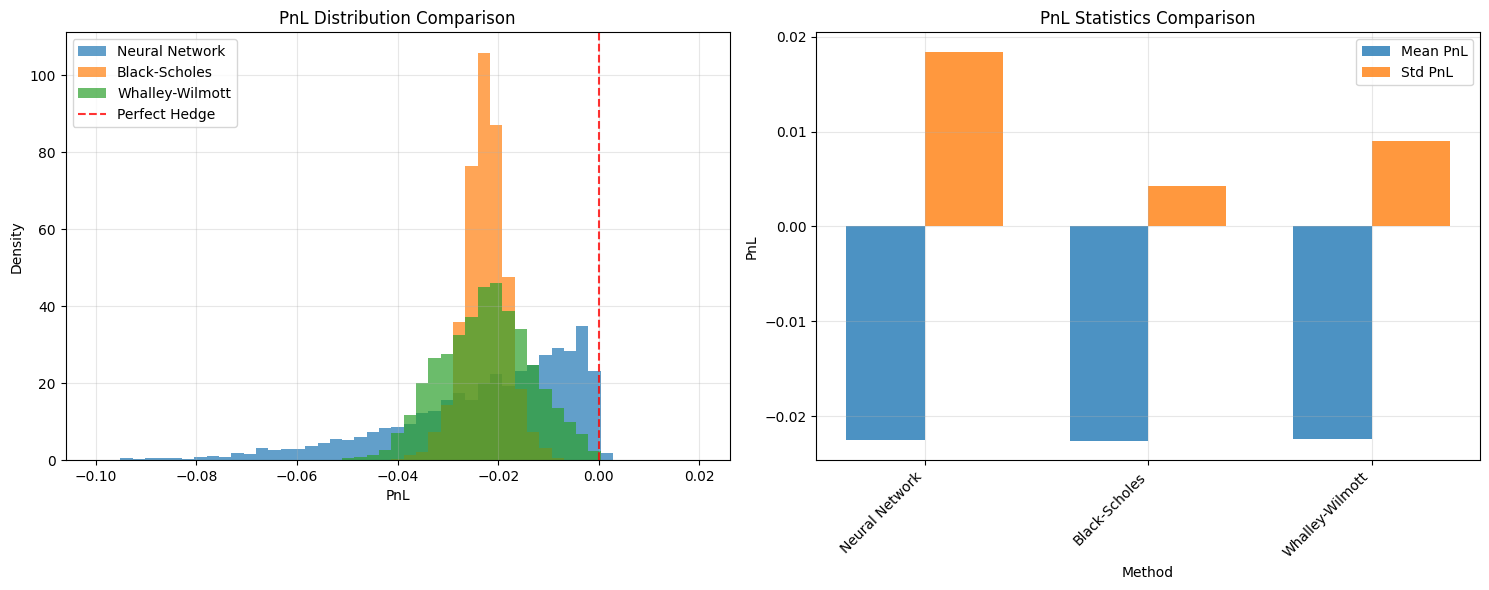


Detailed Statistics:
Method          Mean PnL     Std PnL      Sharpe Ratio
--------------------------------------------------
Neural Network  -0.022508    0.018425     1.2216      
Black-Scholes   -0.022598    0.004269     5.2935      
Whalley-Wilmott -0.022368    0.008996     2.4864      


In [6]:
def visualize_basic_example_results(hedger_nn, hedger_bs, hedger_ww):
    """Visualize the results from the basic example."""

    print("\n=== Visualizing Basic Example Results ===")

    # Create a test derivative for comparison
    test_derivative = EuropeanOption(BrownianStock(cost=1e-4))
    test_derivative.simulate(n_paths=5000, init_state=(1.0,))

    # Compute PnL for each method
    pnl_nn = hedger_nn.compute_pl(test_derivative)
    pnl_bs = hedger_bs.compute_pl(test_derivative)
    pnl_ww = hedger_ww.compute_pl(test_derivative)

    # Create comparison plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1: PnL Distributions
    bins = np.linspace(-0.1, 0.02, 50)
    ax1.hist(pnl_nn.detach().numpy(), bins=bins, alpha=0.7, label='Neural Network', density=True)
    ax1.hist(pnl_bs.detach().numpy(), bins=bins, alpha=0.7, label='Black-Scholes', density=True)
    ax1.hist(pnl_ww.detach().numpy(), bins=bins, alpha=0.7, label='Whalley-Wilmott', density=True)
    ax1.axvline(x=0, color='red', linestyle='--', alpha=0.8, label='Perfect Hedge')
    ax1.set_xlabel('PnL')
    ax1.set_ylabel('Density')
    ax1.set_title('PnL Distribution Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Statistics Comparison
    methods = ['Neural Network', 'Black-Scholes', 'Whalley-Wilmott']
    means = [pnl_nn.mean().item(), pnl_bs.mean().item(), pnl_ww.mean().item()]
    stds = [pnl_nn.std().item(), pnl_bs.std().item(), pnl_ww.std().item()]

    x = np.arange(len(methods))
    width = 0.35

    ax2.bar(x - width/2, means, width, label='Mean PnL', alpha=0.8)
    ax2.bar(x + width/2, stds, width, label='Std PnL', alpha=0.8)
    ax2.set_xlabel('Method')
    ax2.set_ylabel('PnL')
    ax2.set_title('PnL Statistics Comparison')
    ax2.set_xticks(x)
    ax2.set_xticklabels(methods, rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print detailed statistics
    print("\nDetailed Statistics:")
    print("=" * 50)
    print(f"{'Method':<15} {'Mean PnL':<12} {'Std PnL':<12} {'Sharpe Ratio':<12}")
    print("-" * 50)

    for method, pnl in [('Neural Network', pnl_nn), ('Black-Scholes', pnl_bs), ('Whalley-Wilmott', pnl_ww)]:
        mean_pnl = pnl.mean().item()
        std_pnl = pnl.std().item()
        sharpe = -mean_pnl / std_pnl if std_pnl > 0 else 0  # Negative because we want low PnL
        print(f"{method:<15} {mean_pnl:<12.6f} {std_pnl:<12.6f} {sharpe:<12.4f}")

# Visualize the results
visualize_basic_example_results(hedger_nn, hedger_bs, hedger_ww)

## Utility Functions

First, let's define some utility functions that we'll use throughout our experiments. These functions help us:
- Load real market data
- Generate synthetic price paths
- Create derivatives and hedgers
- Set up different risk measures

In [2]:
def load_quotes(file_path: str) -> torch.Tensor:
    """Load stock quotes from CSV file."""
    quotes = pd.read_csv(file_path)
    close = torch.tensor(quotes["Close"].values, dtype=torch.float)
    return close

def generate_log_normal_brownian(
    sigma: float, mu: float, dt: float, n_steps: int, seed: Optional[int] = None
) -> torch.Tensor:
    """Generate a log-normal Brownian motion time series.

    This simulates stock price movements following geometric Brownian motion,
    the foundation of the Black-Scholes model.
    """
    if seed is not None:
        torch.manual_seed(seed)
    # Generate Brownian increments
    increments = torch.randn(n_steps - 1) * np.sqrt(sigma**2 * dt) + mu * dt
    # Convert to log-normal Brownian motion
    log_series = torch.cat([torch.zeros(1), torch.cumsum(increments, dim=0)])
    series = torch.exp(log_series)
    return series

def get_derivative(
    sigma: float, mu: float, dt: float, strike: float, maturity: float, cost: float = 0.0
) -> EuropeanOption:
    """Create a European option with given parameters."""
    stock = BrownianStock(cost=cost, sigma=sigma, mu=mu, dt=dt)
    derivative = EuropeanOption(stock, strike=strike, maturity=maturity)
    return derivative

def create_mlp_hedger(loss_fn, derivative, features, n_epochs, n_paths, init_spot):
    """Create and train a Multi-Layer Perceptron hedger."""
    # Create MLP with 4 layers: input -> 64 -> 32 -> 32 -> 16 -> output
    model = MultiLayerPerceptron(n_layers=4, n_units=[64, 32, 32, 16], activation=ReLU())
    hedger = Hedger(model, features, criterion=loss_fn)

    # Train the hedger
    history = hedger.fit(derivative, n_epochs=n_epochs, n_paths=n_paths, init_state=(init_spot,))
    return hedger, history

def create_blackscholes_hedger(derivative) -> Hedger:
    """Create Black-Scholes analytical hedger for comparison."""
    model = BlackScholes(derivative)
    hedger_bs = Hedger(model, model.inputs())
    return hedger_bs

print("Utility functions defined successfully!")

Utility functions defined successfully!


## Market Setup

Let's set up our market environment using real market data. We'll use the CSI 300 index data and define our option parameters.

In [3]:
# Market parameters
dt = 1 / 250  # Daily time steps (250 trading days per year)
vol = 0.4     # Initial volatility assumption
mu = 0.0      # Risk-neutral drift
init_spot = 3  # Initial stock price
cost = 0.001   # Transaction cost (0.1%)

# Option parameters
strike = 3    # At-the-money option
term = 30     # 30 days to maturity
maturity = term * dt

# Features used by the neural network hedger
features = ["log_moneyness", "expiry_time", "volatility", "prev_hedge"]

# Load real market data (CSI 300 index)
try:
    series = load_quotes("000905.csv")
    fixed_stock = FixedStock(spots=list(series), cost=cost, dt=dt)
    sigma = fixed_stock.volatility  # Use realized volatility
    print(f"Loaded real market data successfully!")
    print(f"Realized Volatility: {sigma:.6f}")
    print(f"Number of price observations: {len(series)}")
except FileNotFoundError:
    print("Market data file not found, using synthetic data...")
    # Generate synthetic data as fallback
    series = generate_log_normal_brownian(sigma=vol, mu=mu, dt=dt, n_steps=1000)
    fixed_stock = FixedStock(spots=list(series), cost=cost, dt=dt)
    sigma = vol
    print(f"Using synthetic data with volatility: {sigma:.6f}")

Loaded real market data successfully!
Realized Volatility: 0.210123
Number of price observations: 1210


## Experiment 1: Basic Hedging Comparison

In this first experiment, we'll compare different risk measures for hedging. This demonstrates one of the key advantages of deep hedging: the ability to optimize for different risk preferences beyond simple variance minimization.

### Risk Measures Explained:
- **Black-Scholes**: Classical delta hedging (variance minimization)
- **Entropic Risk Measure**: Risk-averse measure with parameter `a` controlling risk aversion
- **Expected Shortfall**: Focuses on tail risk (worst-case scenarios)

Running basic hedging comparison...


Loss=0.1139: 100%|██████████| 200/200 [00:35<00:00,  5.60it/s]



PnL Statistics:
Black-Scholes: -0.093882 (0.014203)
Entropic Risk Measure (a=1): -0.089129 (0.067206)
Entropic Risk Measure (a=0.1): -0.087232 (0.133377)
Expected Shortfall (95%): -0.091463 (0.025432)
Expected Shortfall (50%): -0.090466 (0.029877)


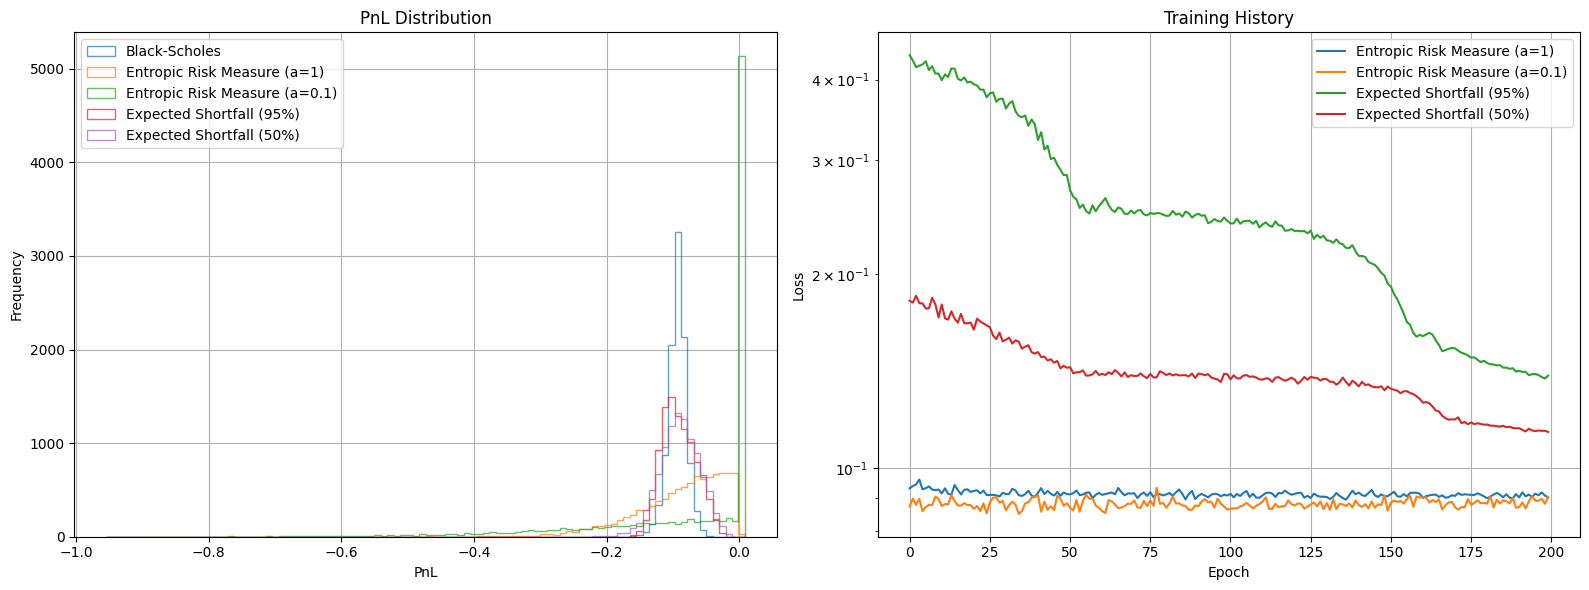

In [5]:
def comprehensive_hedging_experiment(init_spot, strike, cost, n_epochs=200, n_paths=10000):
    """Run a comprehensive hedging experiment comparing different risk measures."""

    torch.manual_seed(1234)  # Ensure reproducibility

    # Define different risk measures
    loss_functions = {
        "Entropic Risk Measure (a=1)": EntropicRiskMeasure(a=1),
        "Entropic Risk Measure (a=0.1)": EntropicRiskMeasure(a=0.1),
        "Expected Shortfall (95%)": ExpectedShortfall(0.05),  # Focus on worst 5%
        "Expected Shortfall (50%)": ExpectedShortfall(0.5),   # Median-based
    }

    hedgers = {}

    # Create Black-Scholes benchmark
    derivative = get_derivative(sigma, mu=mu, dt=dt, cost=cost, strike=strike, maturity=maturity)
    hedger = create_blackscholes_hedger(derivative)
    hedgers["Black-Scholes"] = (hedger, derivative, [])

    # Create ML hedgers for each risk measure
    for name, loss in loss_functions.items():
        derivative = get_derivative(sigma, mu=mu, dt=dt, cost=cost, strike=strike, maturity=maturity)
        hedger, history = create_mlp_hedger(loss, derivative, features, n_epochs, n_paths, init_spot)
        hedgers[name] = (hedger, derivative, history)

    # Evaluate performance
    pnls = {}
    histories = {}
    for name, (hedger, derivative, history) in hedgers.items():
        derivative.simulate(n_paths=10000, init_state=(init_spot,))
        pnls[name] = hedger.compute_pl(derivative)
        histories[name] = history

    # Print statistics
    print("PnL Statistics:")
    for name, pnl in pnls.items():
        print(f"{name}: {pnl.mean():.6f} ({pnl.std():.6f})")

    # Visualize results
    plot_hedging_results(pnls, histories)

    return hedgers

def plot_hedging_results(pnls, histories):
    """Plot PnL distributions and training histories."""

    # Calculate global min and max for uniform binning
    all_pnls = torch.cat([pnl for pnl in pnls.values()]).detach().numpy()
    bin_edges = np.linspace(all_pnls.min(), all_pnls.max(), 101)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot PnL distributions
    for name, pnl in pnls.items():
        ax1.hist(pnl.detach().numpy(), bins=bin_edges, label=name, histtype="step", alpha=0.7)
    ax1.set_title("PnL Distribution")
    ax1.set_xlabel("PnL")
    ax1.set_ylabel("Frequency")
    ax1.legend()
    ax1.grid(True)

    # Plot training histories
    for name, history in histories.items():
        if len(history) > 0:  # Skip Black-Scholes (no training history)
            ax2.plot(history, label=name)
    ax2.set_title("Training History")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.set_yscale('log')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Run the basic experiment
print("Running basic hedging comparison...")
hedgers_basic = comprehensive_hedging_experiment(init_spot=3, strike=3, cost=0.001, n_epochs=200, n_paths=10000)

## Experiment 2: Training Dynamics - Effect of Epochs

This experiment investigates how the number of training epochs affects hedging performance. Understanding this is crucial for practical implementation as it involves the trade-off between computation time and hedge quality.

Experiment 2: Effect of Training Epochs

Training with 1 epochs:
------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

Loss=0.0588: 100%|██████████| 1/1 [00:00<00:00,  5.99it/s]



PnL Statistics:
Black-Scholes: -0.029112 (0.004596)
Entropic Risk Measure (a=1): -0.029118 (0.034968)
Entropic Risk Measure (a=0.1): -0.028837 (0.046726)
Expected Shortfall (95%): -0.029236 (0.040224)
Expected Shortfall (50%): -0.028942 (0.042427)


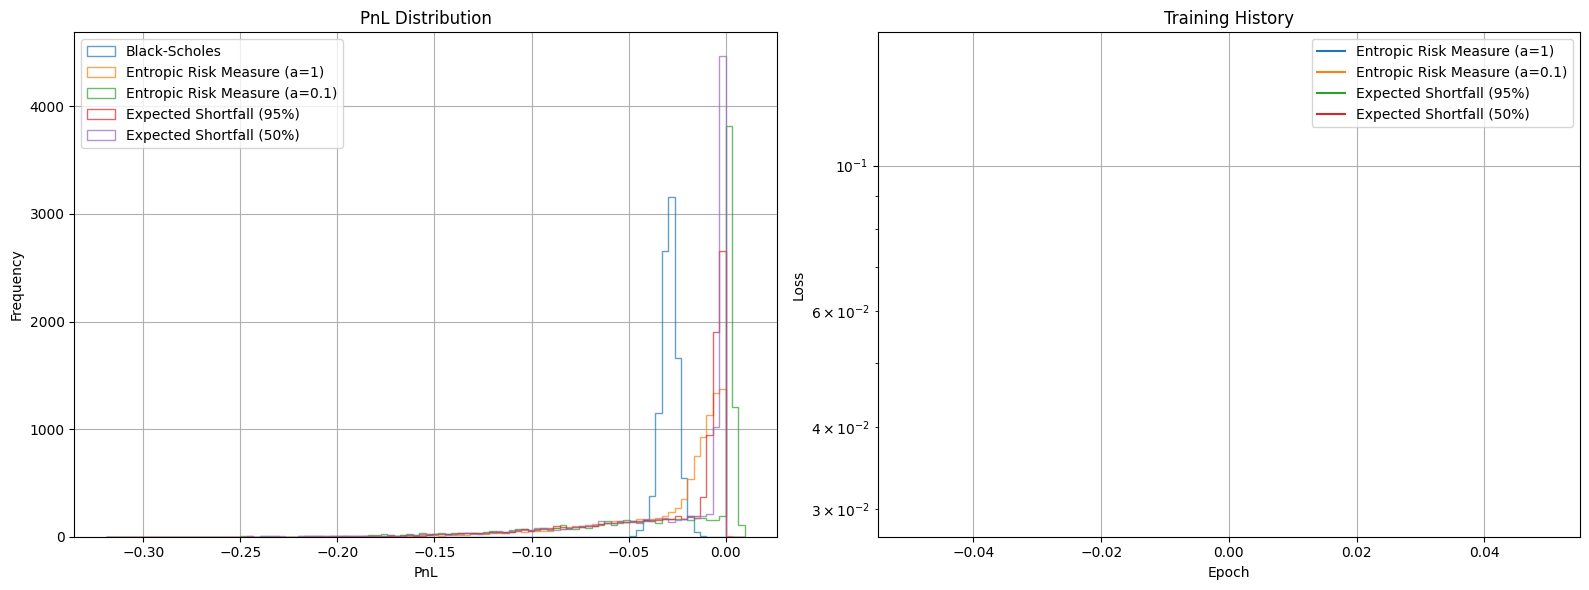


Training with 10 epochs:
------------------------------


Loss=0.0549: 100%|██████████| 10/10 [00:01<00:00,  5.83it/s]



PnL Statistics:
Black-Scholes: -0.029060 (0.004506)
Entropic Risk Measure (a=1): -0.029236 (0.030246)
Entropic Risk Measure (a=0.1): -0.028347 (0.030596)
Expected Shortfall (95%): -0.029381 (0.036217)
Expected Shortfall (50%): -0.028861 (0.041671)


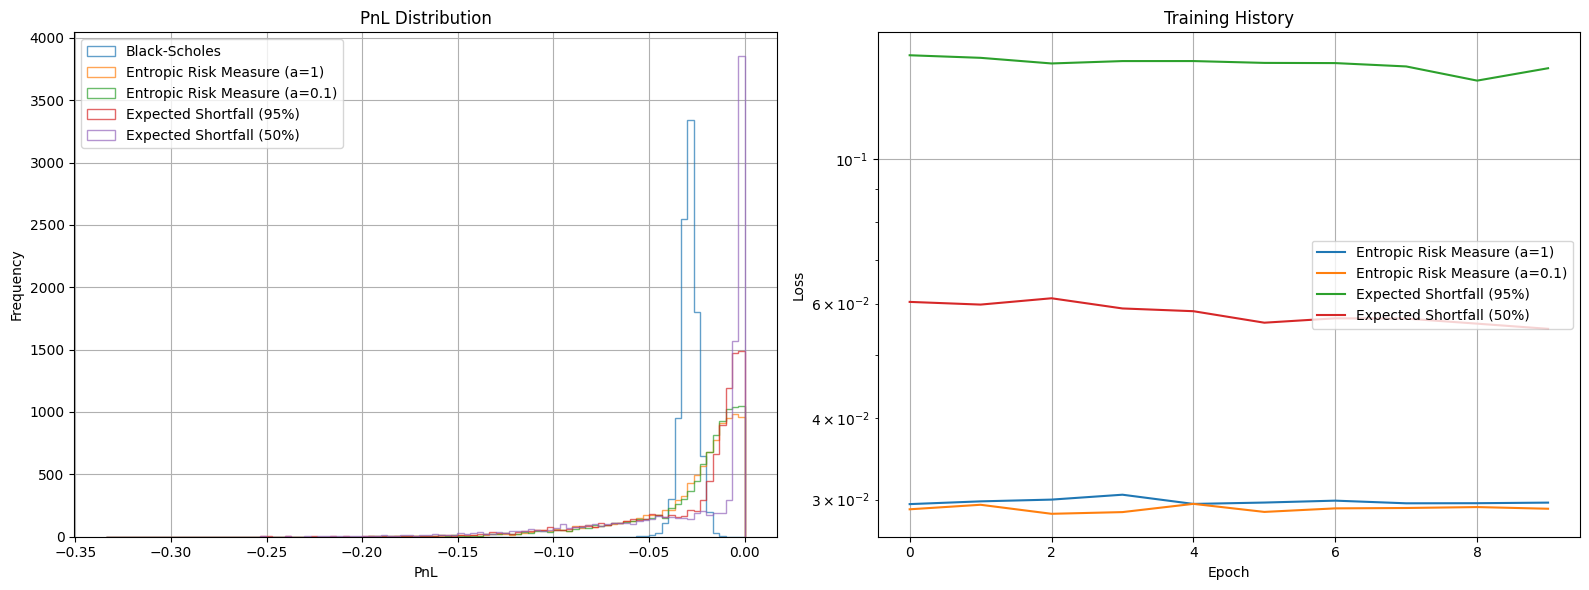


Training with 100 epochs:
------------------------------


Loss=0.0455: 100%|██████████| 100/100 [00:16<00:00,  5.95it/s]



PnL Statistics:
Black-Scholes: -0.029077 (0.004589)
Entropic Risk Measure (a=1): -0.028899 (0.021981)
Entropic Risk Measure (a=0.1): -0.029514 (0.032663)
Expected Shortfall (95%): -0.028952 (0.020859)
Expected Shortfall (50%): -0.029113 (0.020687)


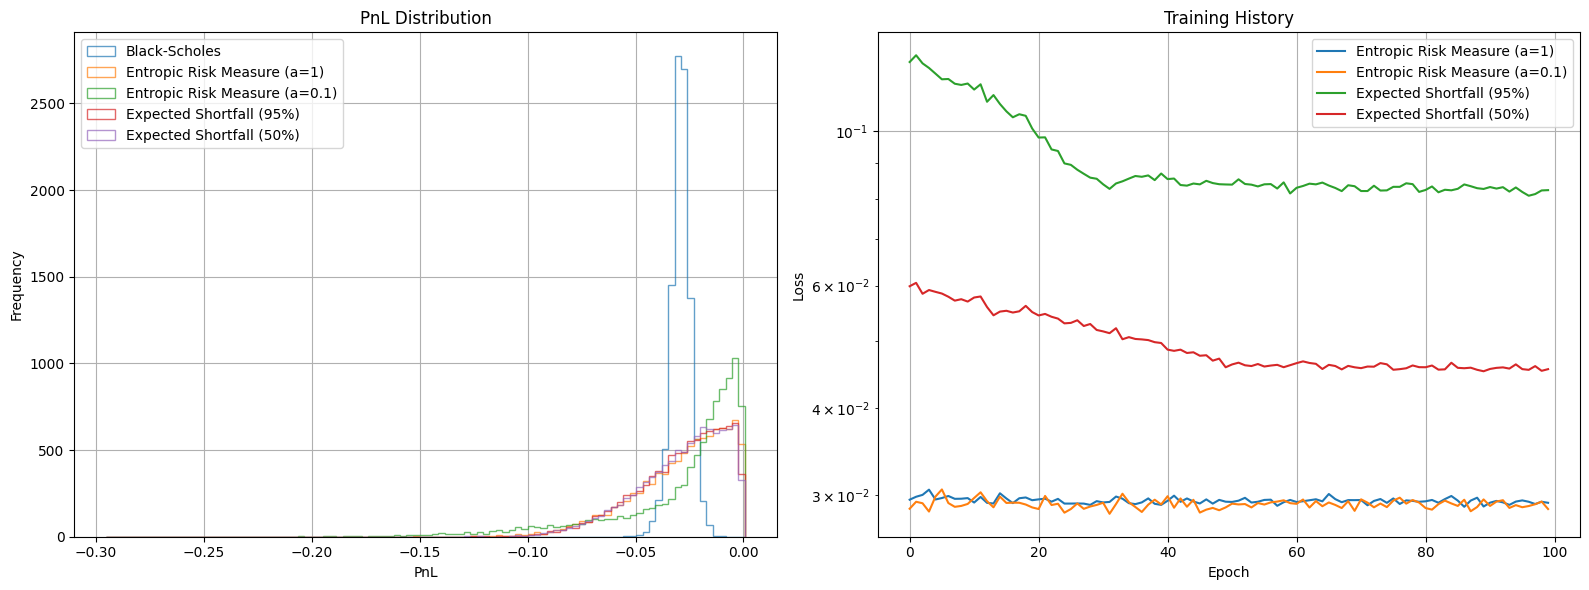

In [6]:
print("Experiment 2: Effect of Training Epochs")
print("=" * 50)

# Test with different numbers of epochs
epoch_experiments = [1, 10, 100]

for n_epochs in epoch_experiments:
    print(f"\nTraining with {n_epochs} epochs:")
    print("-" * 30)
    hedgers = comprehensive_hedging_experiment(
        init_spot=1, strike=1, cost=0,
        n_epochs=n_epochs, n_paths=10000
    )

## Experiment 3: Backtest on Real Market Data

Now let's test our trained hedgers on actual historical market data. This is crucial for understanding how the strategies would have performed in real market conditions.

Backtest Results:
Backtesting on 1180 historical paths...
Black-Scholes: -0.080430 (0.024508)
Entropic Risk Measure (a=1): -0.080855 (0.085168)
Entropic Risk Measure (a=0.1): -0.087082 (0.169828)
Expected Shortfall (95%): -0.080560 (0.038866)
Expected Shortfall (50%): -0.080102 (0.045872)


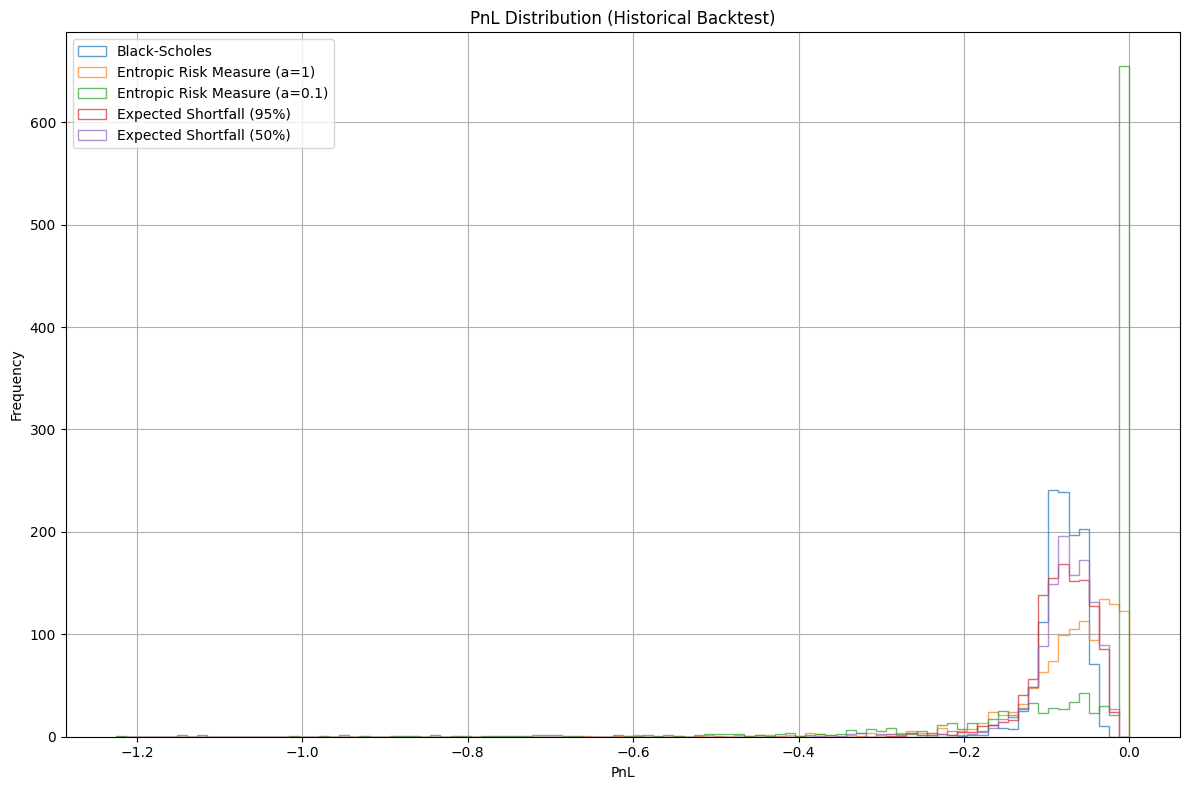

In [7]:
def backtest_on_fixed_stock(hedgers, fixed_stock, strike, init_spot):
    """Backtest hedgers on historical data."""

    # Create derivative using fixed (historical) stock
    fixed_derivative = EuropeanOption(fixed_stock, strike=strike, maturity=maturity)

    # Use all available historical paths
    n_paths = fixed_stock.max_n_paths(maturity)
    fixed_derivative.simulate(n_paths=n_paths, init_state=(init_spot,))

    print(f"Backtesting on {n_paths} historical paths...")

    backtest_pnls = {}
    for name, (hedger, _) in hedgers.items():
        pnl = hedger.compute_pl(fixed_derivative)
        backtest_pnls[name] = pnl
        print(f"{name}: {pnl.mean():.6f} ({pnl.std():.6f})")

    # Plot backtest results
    all_pnls = torch.cat([pnl for pnl in backtest_pnls.values()]).detach().numpy()
    bin_edges = np.linspace(all_pnls.min(), all_pnls.max(), 101)

    plt.figure(figsize=(12, 8))
    for name, pnl in backtest_pnls.items():
        plt.hist(pnl.detach().numpy(), bins=bin_edges, label=name, histtype="step", alpha=0.7)
    plt.title("PnL Distribution (Historical Backtest)")
    plt.xlabel("PnL")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return backtest_pnls

# Extract hedgers from basic experiment (remove history for compatibility)
hedgers_for_backtest = {name: (hedger, derivative) for name, (hedger, derivative, _) in hedgers_basic.items()}

print("Backtest Results:")
print("=" * 50)
backtest_results = backtest_on_fixed_stock(hedgers_for_backtest, fixed_stock, strike=3, init_spot=3)

## Experiment 4: Daily PnL Analysis

Let's examine the day-by-day performance of different hedging strategies on selected historical paths. This gives us insight into how the strategies behave during different market conditions.

Daily PnL Analysis:


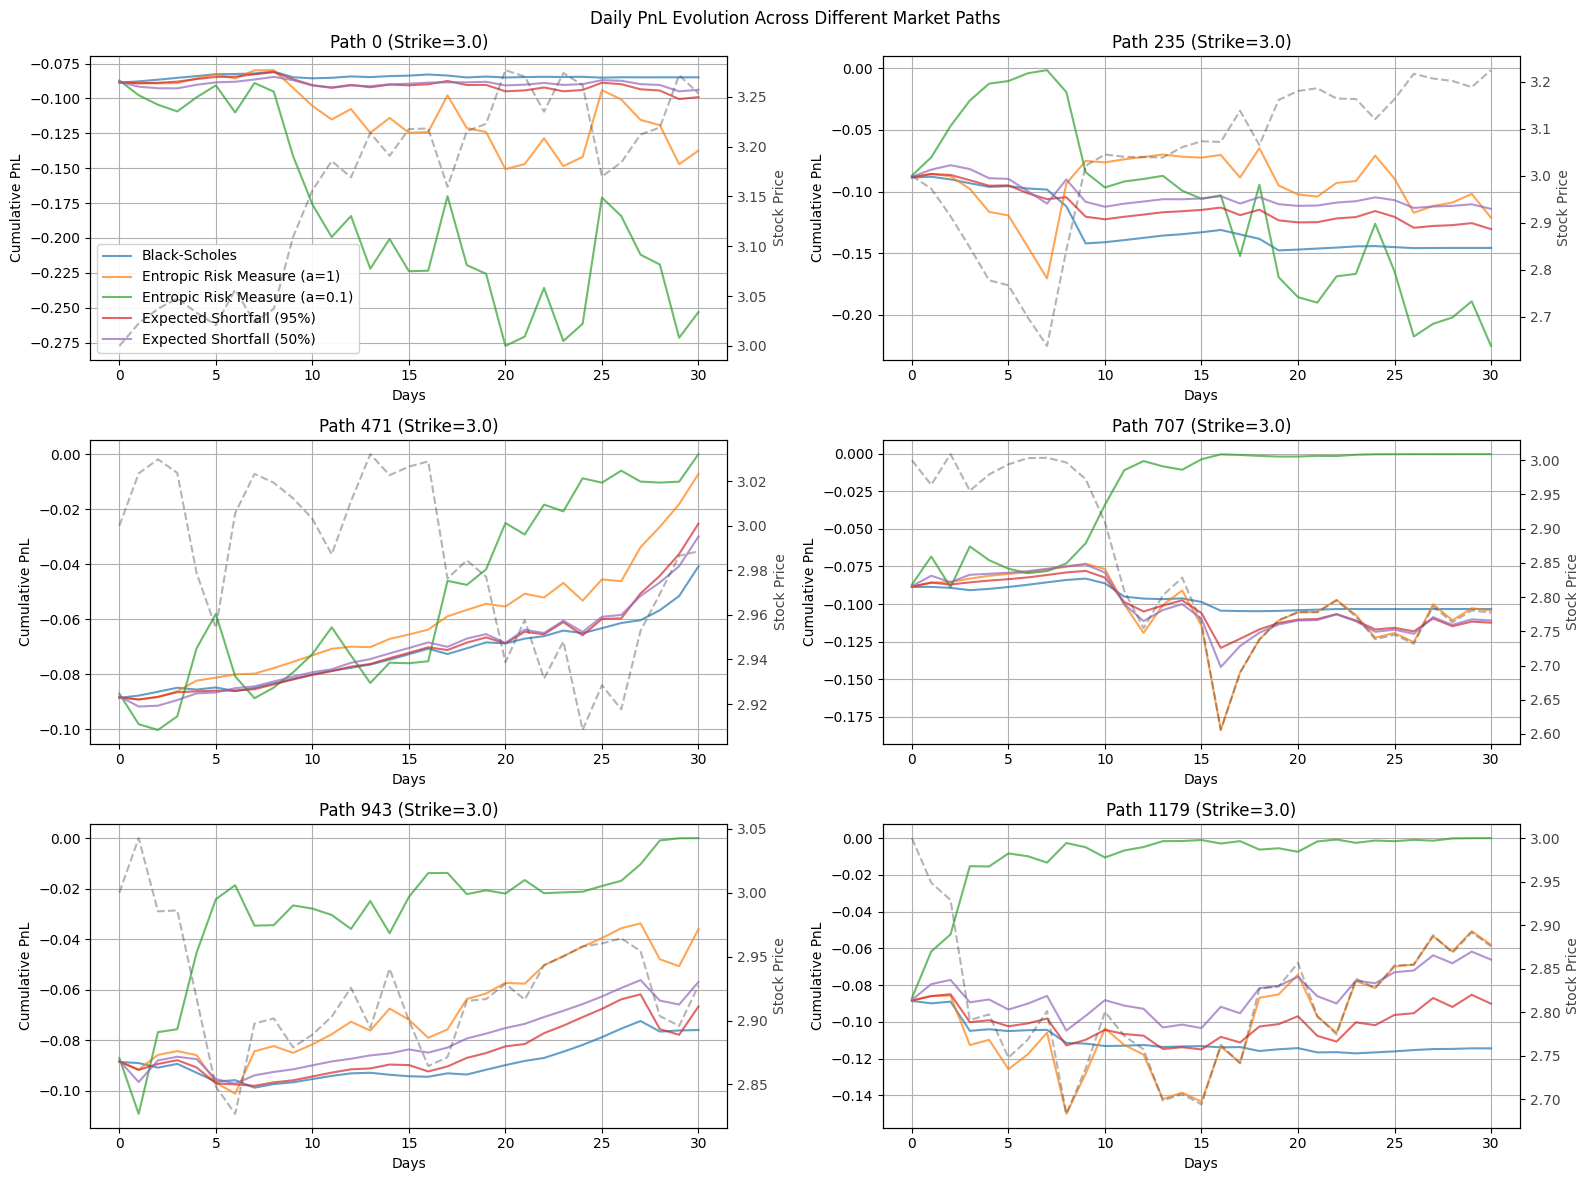

In [8]:
def analyze_daily_pnl(hedgers, fixed_derivative, fixed_stock, n_paths_to_show=10):
    """Analyze daily PnL evolution for selected paths."""

    # Create Black-Scholes pricer for reference
    bs_priceable = BSEuropeanOption.from_derivative(fixed_derivative)

    # Select paths to analyze
    max_paths = fixed_stock.max_n_paths(maturity)
    path_indices = torch.linspace(0, max_paths - 1, n_paths_to_show).long()

    # Compute cumulative PnL for each hedger
    daily_pnls = {}
    for name, (hedger, _) in hedgers.items():
        daily_pnls[name] = hedger.compute_cum_pl(fixed_derivative, priceable=bs_priceable)[path_indices]

    # Get corresponding stock paths
    stock_paths = fixed_stock.spot[path_indices]

    # Create subplot grid
    n_cols = 2
    n_rows = (n_paths_to_show + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    colors = plt.cm.tab10.colors

    # Plot each path
    for path_idx, ax in enumerate(axes.flat):
        if path_idx >= n_paths_to_show:
            ax.set_visible(False)
            continue

        # Plot hedging strategies' PnL
        for i, (name, pnl) in enumerate(daily_pnls.items()):
            pnl_path = pnl[path_idx].detach().numpy()
            color = colors[i % len(colors)]
            ax.plot(pnl_path, color=color, label=name, alpha=0.7)

        # Create twin axis for stock price
        ax2 = ax.twinx()
        stock_price = stock_paths[path_idx].squeeze().detach().numpy()
        ax2.plot(stock_price, color='#444444', linestyle='--', alpha=0.4, label='Stock Price')
        ax2.set_ylabel('Stock Price', color='#444444')
        ax2.tick_params(axis='y', labelcolor='#444444')

        ax.set_title(f"Path {path_indices[path_idx].item()} (Strike={fixed_derivative.strike:.1f})")
        ax.set_xlabel("Days")
        ax.set_ylabel("Cumulative PnL")
        ax.grid(True)

        # Add legend to first subplot
        if path_idx == 0:
            ax.legend(framealpha=0.9)

    plt.suptitle("Daily PnL Evolution Across Different Market Paths")
    plt.tight_layout()
    plt.show()

# Run daily PnL analysis
print("Daily PnL Analysis:")
print("=" * 50)
analyze_daily_pnl(hedgers_for_backtest,
                 EuropeanOption(fixed_stock, strike=3, maturity=maturity),
                 fixed_stock, n_paths_to_show=6)

## Experiment 5: Cross-Validation Analysis

This experiment tests the robustness of our trained models by evaluating how well hedgers trained with one loss function perform when evaluated using different loss functions. This is important for understanding model generalization.

In [9]:
def cross_validation_experiment(hedgers_dict, test_strikes=[1, 10, 100]):
    """Test cross-performance between different models and loss functions."""

    print("Cross-Validation Results:")
    print("=" * 50)

    for strike in test_strikes:
        print(f"\nTesting on strike = {strike}")
        print("-" * 30)

        # Create test derivative
        fixed_paths = fixed_stock.max_n_paths(maturity)
        test_stock = FixedStock(spots=list(series), cost=0, dt=dt)
        test_derivative = EuropeanOption(test_stock, strike=strike, maturity=maturity)

        # Cross-validation matrix
        losses = []

        for model_name, (hedger_model, _, _) in hedgers_dict.items():
            if model_name == "Black-Scholes":
                continue

            for loss_name, (hedger_loss, _, _) in hedgers_dict.items():
                if loss_name == "Black-Scholes":
                    continue

                # Create hedger with model from one training and loss from another
                hedger = Hedger(hedger_model.model, features, hedger_loss.criterion)
                loss = hedger.compute_loss(
                    test_derivative,
                    n_paths=fixed_paths,
                    init_state=(strike,),
                    enable_grad=False
                )
                losses.append((model_name, loss_name, loss.item()))

        # Create and display results table
        df = pd.DataFrame(losses, columns=["Model", "Loss Function", "Loss Value"])
        pivot_table = df.pivot(index="Model", columns="Loss Function", values="Loss Value")
        print(pivot_table.round(6))

# Run cross-validation
cross_validation_experiment(hedgers_basic)

Cross-Validation Results:

Testing on strike = 1
------------------------------
Loss Function                  Entropic Risk Measure (a=0.1)  \
Model                                                          
Entropic Risk Measure (a=0.1)                       0.029187   
Entropic Risk Measure (a=1)                         0.026526   
Expected Shortfall (50%)                            0.025640   
Expected Shortfall (95%)                            0.025496   

Loss Function                  Entropic Risk Measure (a=1)  \
Model                                                        
Entropic Risk Measure (a=0.1)                     0.030731   
Entropic Risk Measure (a=1)                       0.026899   
Expected Shortfall (50%)                          0.025747   
Expected Shortfall (95%)                          0.025571   

Loss Function                  Expected Shortfall (50%)  \
Model                                                     
Entropic Risk Measure (a=0.1)               

## Experiment 6: Effect of Sample Size

Let's investigate how the number of training paths affects the quality of the learned hedging strategy.

Sample Size Experiment:

Training with 1000 paths:
------------------------------


Loss=0.1393: 100%|██████████| 100/100 [00:03<00:00, 27.07it/s]



PnL Statistics:
Black-Scholes: -0.087242 (0.013490)
Entropic Risk Measure (a=1): -0.086378 (0.065438)
Entropic Risk Measure (a=0.1): -0.085422 (0.090062)
Expected Shortfall (95%): -0.087315 (0.073266)
Expected Shortfall (50%): -0.087188 (0.063358)


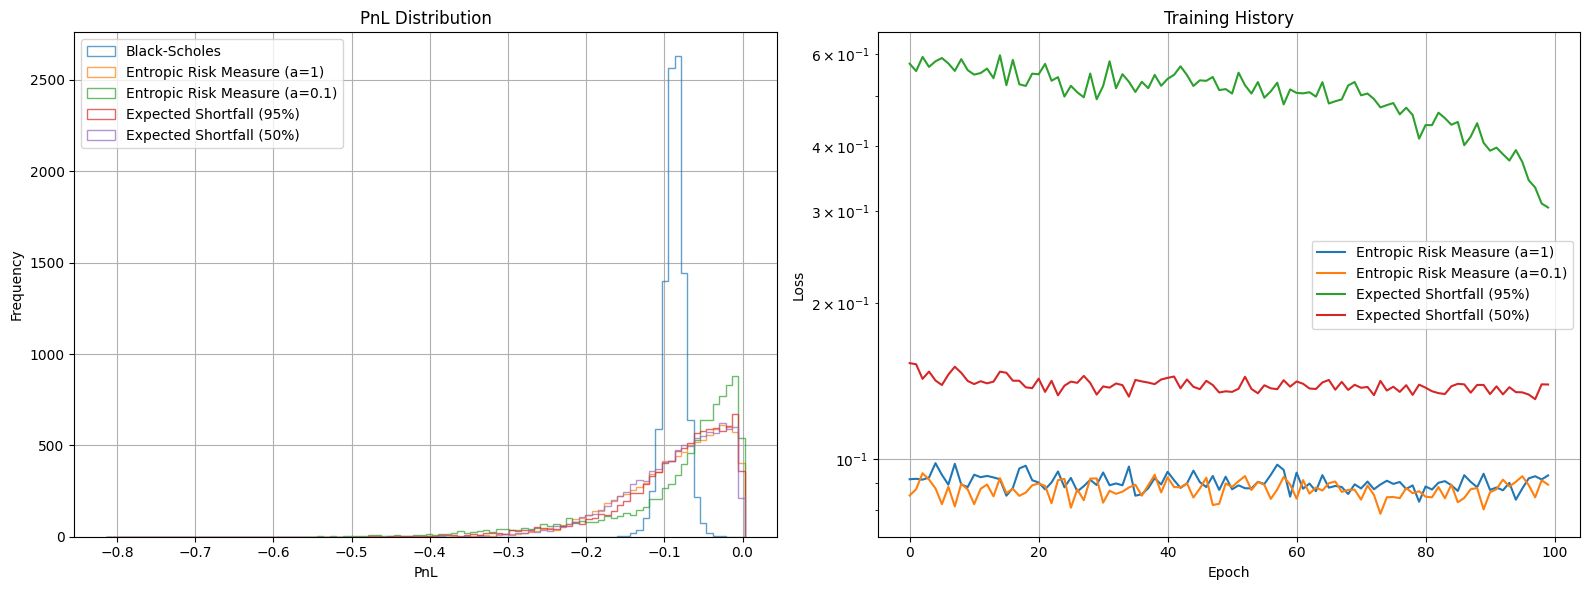


Training with 10000 paths:
------------------------------


Loss=0.1364: 100%|██████████| 100/100 [00:16<00:00,  6.13it/s]



PnL Statistics:
Black-Scholes: -0.087231 (0.013768)
Entropic Risk Measure (a=1): -0.086644 (0.065752)
Entropic Risk Measure (a=0.1): -0.087782 (0.067078)
Expected Shortfall (95%): -0.086857 (0.062581)
Expected Shortfall (50%): -0.087336 (0.062021)


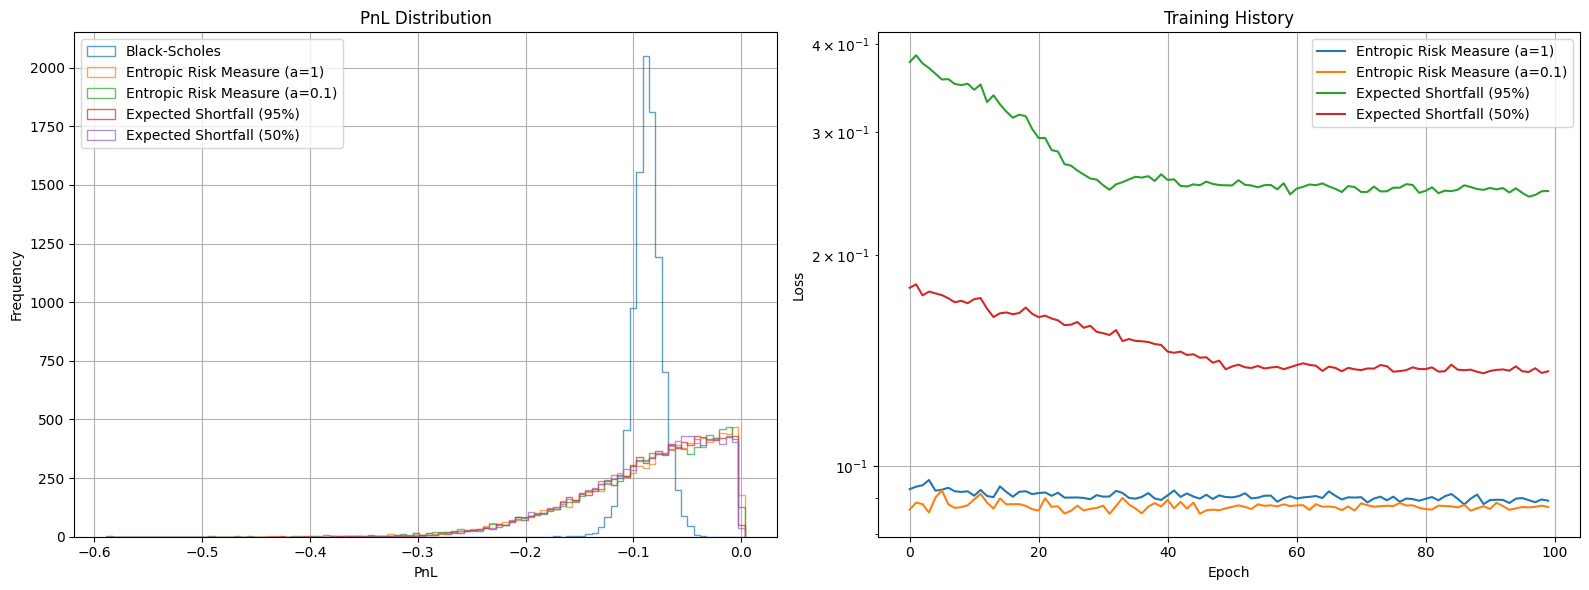


Training with 100000 paths:
------------------------------


Loss=0.1365: 100%|██████████| 100/100 [03:33<00:00,  2.14s/it]



PnL Statistics:
Black-Scholes: -0.087076 (0.013456)
Entropic Risk Measure (a=1): -0.086521 (0.064861)
Entropic Risk Measure (a=0.1): -0.086449 (0.063286)
Expected Shortfall (95%): -0.087117 (0.062402)
Expected Shortfall (50%): -0.086723 (0.061176)


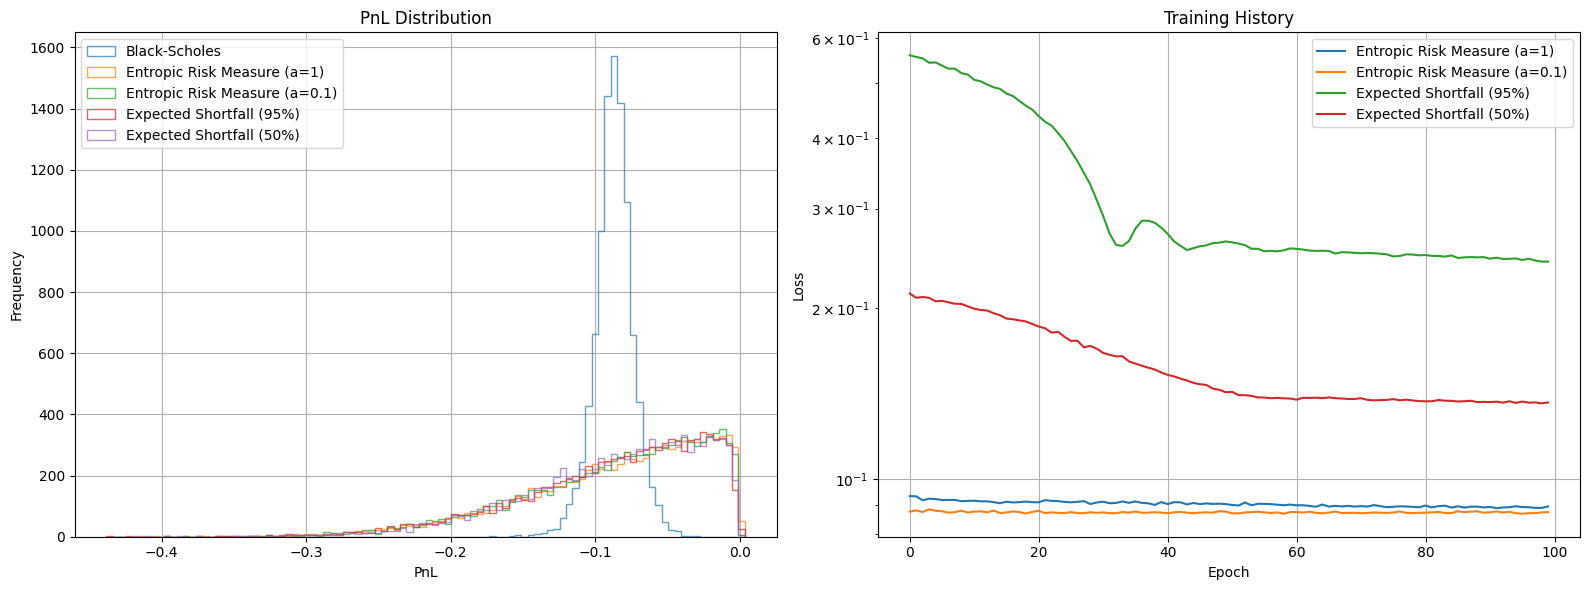

Sample size experiment code ready (uncomment to run)


In [10]:
def sample_size_experiment():
    """Investigate effect of training sample size."""

    print("Sample Size Experiment:")
    print("=" * 50)

    sample_sizes = [1000, 10000, 100000]

    for n_paths in sample_sizes:
        print(f"\nTraining with {n_paths} paths:")
        print("-" * 30)

        hedgers = comprehensive_hedging_experiment(
            init_spot=3, strike=3, cost=0,
            n_epochs=100, n_paths=n_paths
        )

# Run sample size experiment (commented out for performance - uncomment to run)
sample_size_experiment()
print("Sample size experiment code ready (uncomment to run)")

## Experiment 7: Multi-Strike Analysis

Finally, let's test a comprehensive scenario from the vanilla.py file, where we train multiple hedgers for different strikes and maturities, then cross-test their performance.

Multi-Strike Analysis:
Training hedger for ATM, 30d...


Loss=0.0361: 100%|██████████| 200/200 [00:18<00:00, 10.76it/s]


Training hedger for OTM, 30d...


Loss=0.0224: 100%|██████████| 200/200 [00:18<00:00, 10.77it/s]


Training hedger for ATM, 15d...


Loss=0.0267: 100%|██████████| 200/200 [00:09<00:00, 20.57it/s]


Training hedger for OTM, 15d...


Loss=0.0158: 100%|██████████| 200/200 [00:08<00:00, 22.28it/s]


Training hedger for Deep OTM...


Loss=3.3050: 100%|██████████| 200/200 [00:18<00:00, 11.08it/s]



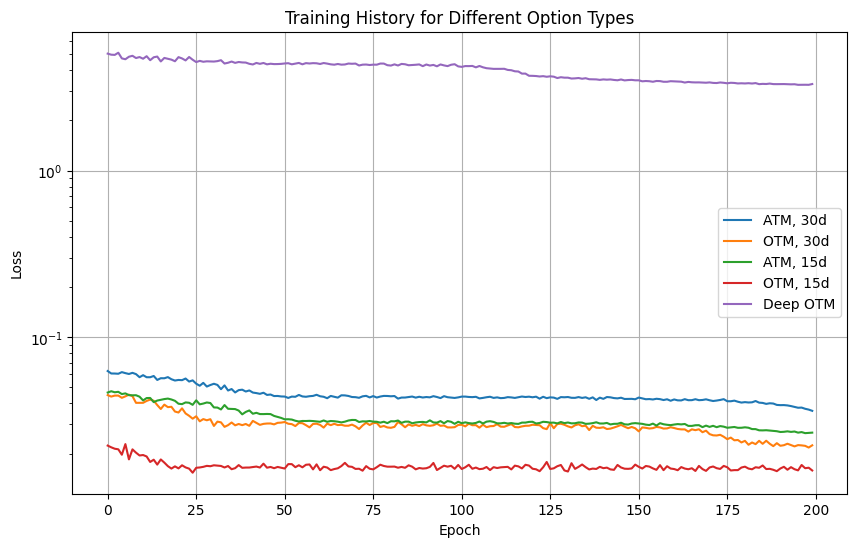


Cross-Testing Results:
------------------------------
          ATM, 30d  OTM, 30d  ATM, 15d  OTM, 15d  Deep OTM
ATM, 30d  0.036325  0.024463  0.027625  0.016875  3.619492
OTM, 30d  0.035700  0.022523  0.028036  0.014245  3.560720
ATM, 15d  0.037919  0.025864  0.026583  0.016836  3.811057
OTM, 15d  0.050127  0.030164  0.036560  0.016126  5.009933
Deep OTM  0.032970  0.020699  0.024870  0.013240  3.281270
          ATM, 30d  OTM, 30d  ATM, 15d  OTM, 15d  Deep OTM
ATM, 30d  0.036325  0.024463  0.027625  0.016875  3.619492
OTM, 30d  0.035700  0.022523  0.028036  0.014245  3.560720
ATM, 15d  0.037919  0.025864  0.026583  0.016836  3.811057
OTM, 15d  0.050127  0.030164  0.036560  0.016126  5.009933
Deep OTM  0.032970  0.020699  0.024870  0.013240  3.281270


In [11]:
def multi_strike_analysis():
    """Comprehensive analysis across multiple strikes and maturities."""

    print("Multi-Strike Analysis:")
    print("=" * 50)

    torch.manual_seed(42)

    # Market parameters
    sigma = 0.2
    mu = 0.0
    cost = 1e-4
    init_spot = 1.0
    n_epochs = 200
    n_paths = 5000

    # Create Expected Shortfall loss function
    loss = ExpectedShortfall(0.5)

    # Define test cases
    test_cases = [
        {"name": "ATM, 30d", "strike": 1.0, "maturity": 30/250, "init_state": 1.0},
        {"name": "OTM, 30d", "strike": 1.03, "maturity": 30/250, "init_state": 1.0},
        {"name": "ATM, 15d", "strike": 1.0, "maturity": 15/250, "init_state": 1.0},
        {"name": "OTM, 15d", "strike": 1.03, "maturity": 15/250, "init_state": 1.0},
        {"name": "Deep OTM", "strike": 100.0, "maturity": 30/250, "init_state": 100.0},
    ]

    hedgers = []
    derivatives = []
    histories = []

    # Train hedgers for each case
    for case in test_cases:
        print(f"Training hedger for {case['name']}...")

        derivative = EuropeanOption(
            BrownianStock(sigma=sigma, mu=mu, cost=cost),
            call=True,
            strike=case["strike"],
            maturity=case["maturity"],
        )

        features = ["log_moneyness", "expiry_time", "volatility", "prev_hedge"]
        model = MultiLayerPerceptron(n_layers=4, n_units=[64, 32, 32, 16])
        hedger = Hedger(model, features, criterion=loss)

        history = hedger.fit(
            derivative,
            n_epochs=n_epochs,
            n_paths=n_paths,
            init_state=(case["init_state"],)
        )

        hedgers.append(hedger)
        derivatives.append(derivative)
        histories.append(history)

    # Plot training histories
    plt.figure(figsize=(10, 6))
    for i, (case, history) in enumerate(zip(test_cases, histories)):
        plt.plot(history, label=case["name"])
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.yscale("log")
    plt.title("Training History for Different Option Types")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Cross-test performance
    print("\nCross-Testing Results:")
    print("-" * 30)

    # Simulate all derivatives
    for i, (derivative, case) in enumerate(zip(derivatives, test_cases)):
        derivative.simulate(n_paths=n_paths, init_state=(case["init_state"],))

    # Compute cross-losses
    losses = []
    for i, (hedger, case_hedger) in enumerate(zip(hedgers, test_cases)):
        row = []
        for j, (derivative, case_deriv) in enumerate(zip(derivatives, test_cases)):
            loss_val = hedger.compute_loss(
                derivative,
                n_paths=n_paths,
                init_state=(case_deriv["init_state"],),
                enable_grad=False
            ).item()
            row.append(loss_val)
        losses.append(row)

    # Create results DataFrame
    hedger_names = [case["name"] for case in test_cases]
    derivative_names = [case["name"] for case in test_cases]

    df = pd.DataFrame(losses, columns=derivative_names, index=hedger_names)
    print(df.round(6))

    return hedgers, derivatives, histories

# Run multi-strike analysis
hedgers_multi, derivatives_multi, histories_multi = multi_strike_analysis()

## Summary and Key Insights

### What We've Learned:

1. **Deep Hedging vs Black-Scholes**: Deep learning methods can optimize for different risk measures beyond simple variance minimization, potentially leading to better risk-adjusted performance.

2. **Training Dynamics**: More training epochs generally improve performance, but with diminishing returns. The optimal number depends on the complexity of the problem.

3. **Risk Measures Matter**: Different risk measures (Entropic Risk, Expected Shortfall) lead to different hedging strategies, each suitable for different risk preferences.

4. **Real Data Performance**: Backtesting on historical data provides crucial validation of strategy robustness.

5. **Cross-Validation**: Models trained with one risk measure may not perform optimally when evaluated with different criteria, highlighting the importance of aligning training and evaluation objectives.

### Practical Considerations:

- **Computational Cost**: Training neural network hedgers requires significant computation compared to analytical solutions
- **Data Requirements**: Deep hedging benefits from large amounts of training data
- **Generalization**: Models need to be tested across different market conditions and option specifications
- **Risk Management**: Different risk measures are appropriate for different market participants and risk tolerances

### Next Steps:

1. Experiment with different neural network architectures
2. Test on more complex derivatives (American options, exotics)
3. Incorporate more sophisticated features (implied volatility, market sentiment)
4. Implement real-time hedging systems
5. Consider transaction costs and market impact in more detail

This notebook provides a foundation for understanding pfhedge and deep hedging concepts. The library's flexibility allows for extensive experimentation and customization for specific trading strategies and risk management needs.